# Clustering — grouping 5000 customers nobody labelled

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

## The story we will follow

You work for a shop that has 5000 customers. For every customer the system stores two numbers.

Nobody ever wrote down what *kind* of customer each one is. That column does not exist, and
nobody is going to fill it in by hand for 5000 rows.

Your manager asks one question:

> "How many kinds of customers do we actually have, and who belongs to which kind?"

That question is clustering.

## Why this is different from everything before

| | every earlier notebook | this notebook |
|---|---|---|
| the data | `x` and `y` | only `x` |
| the job | predict the answer someone gave you | find groups nobody wrote down |
| example | this house costs 45 lakh | these 1200 customers behave alike |

## K-Means in one line

Two things, repeated:

- **distance** — every point joins the nearest centre
- **average** — every centre moves to the middle of its own points

Repeat until nothing moves. That is the whole algorithm.


In [1]:
from sklearn.datasets import make_blobs,make_moons
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. The 5000 customers

`make_blobs` invents the data. It is not real shop data. It is practice data built to contain
clear groups, so we can check whether the model finds them.

- `n_samples=5000` — 5000 customers
- `n_features=2` — 2 numbers per customer, so everything fits on a flat graph
- `centers=4` — it secretly builds 4 groups

The invented numbers can be negative, so do not read them as rupees. Just read every dot as
**one customer described by two measurements**.

`y` holds the true group of each customer. **In real work this column does not exist.** We will
look at it exactly once, only to check ourselves, and never to train the model.


In [2]:
x,y = make_blobs(n_features=2,n_samples=5000,centers=4)

## 2. First look

Before any model, just plot the customers and look.


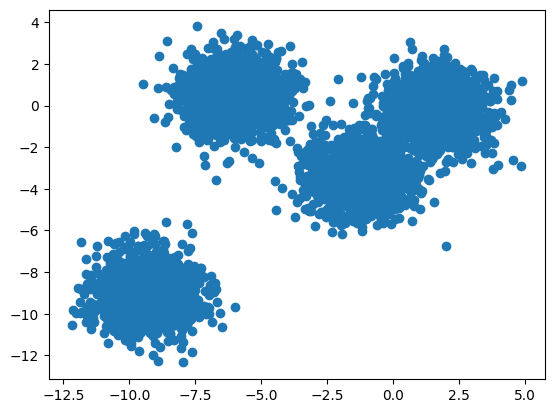

In [3]:
plt.scatter(x[:,0],x[:,1])

The same picture again, with the four real groups named on top of it.

This uses `y`, which is cheating. We do it once so you can see the answer the model is supposed
to reach on its own.


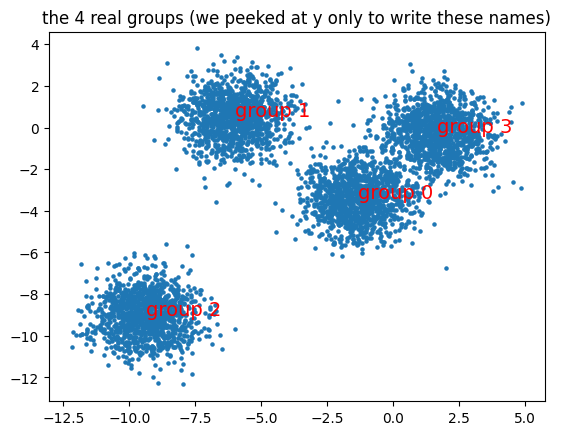

In [4]:
plt.scatter(x[:, 0], x[:, 1], s=5)

for group in range(4):
    plt.text(x[y == group, 0].mean(), x[y == group, 1].mean(), f"group {group}",
             fontsize=14, color="red")

plt.title("the 4 real groups (we peeked at y only to write these names)")
plt.show()

Four clumps of customers.

One thing to expect: **this picture changes every time you re-run the notebook.** `make_blobs`
picks new positions each run because we did not fix a random seed. Sometimes two groups land
close enough to touch, sometimes all four sit far apart. The shapes stay round either way.


## 3. The algorithm you worked out by hand

`KMeans` does exactly the steps you did on paper:

1. pick `K` — how many groups you want
2. drop `K` centroids anywhere
3. **distance** — every customer joins the nearest centroid
4. **average** — every centroid moves to the middle of its own customers
5. repeat 3 and 4 until nobody changes group

A centroid is not a real customer. It is a marker sitting at the middle of a group, like a
teacher standing in the middle of their own students.


In [5]:
from sklearn.cluster import KMeans

### Why `n_clusters=4`?

Because we built the data with 4 groups, so we know the answer.

In real work nobody tells you. Then you use the **elbow method** from your notes: run K-Means
for K = 1, 2, 3, 4, 5..., and each time measure the total distance of every point from its own
centroid. That total always falls as K grows, so the smallest value is a useless rule. You look
for the **bend** in the curve — the K after which extra groups stop helping.


In [6]:
kmeans = KMeans(n_clusters=4)

### `.fit()` — what actually gets stored

`.fit()` runs the whole loop and then keeps one thing: the final position of the 4 centroids.


In [7]:
kmeans.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)",

In [8]:
kmeans.cluster_centers_

array([[-6.01051572,  0.53284882],
       [-9.36776321, -9.00853513],
       [ 1.64764966, -0.24159491],
       [-1.34399725, -3.39635862]])

Four rows, two numbers each. **Eight numbers.**

That is the entire trained model. Not 5000 rows — just 8 numbers. Remember this, because the
next section depends on it.


## 4. Your question: clustering only makes groups, so what does it predict?

Good question. The answer is that K-Means does **two different jobs**, and they are easy to mix
up.

**Job 1 — grouping.** `.fit()` looks at all 5000 customers and decides who belongs with whom.
This is the job clustering is famous for.

**Job 2 — predicting.** A **new** customer walks in tomorrow, one the model has never seen.
`.predict()` measures that new customer against the 4 stored centroids and returns the number
of the nearest one.

So, what does clustering predict?

> It does not predict a value like price or salary.
> It predicts **which existing group a new row belongs to.**

That is all. It cannot invent a fifth group, and it cannot tell you what a group *means* —
deciding that group 2 is "our loyal big spenders" is still a human job.

### Why your line looks like it did nothing

You wrote `kmeans.predict(x)` on the **same `x`** the model was fitted on. So it simply handed
back the group of every customer it had already grouped. Nothing new could come out of it. The
next cell proves that.


In [9]:
predict = kmeans.predict(x)

### Proof: on the same data, `predict` only repeats what `fit` already decided


In [10]:
print("predict :", predict[:8])
print("labels_ :", kmeans.labels_[:8])
print("same answer?", (predict == kmeans.labels_).all())

predict : [2 0 2 1 3 1 1 3]
labels_ : [2 0 2 1 3 1 1 3]
same answer? True


`True`. Same answer both times.

`labels_` is the grouping produced by `.fit()`. `predict(x)` measured those same 5000 customers
against the same 4 centroids, so of course it got the same result.


### Now a customer the model has never seen

A new customer walks in tomorrow. They were not part of the 5000, and the model was never
trained on them.

To keep the story concrete: their two numbers are very close to customer 0's numbers. We take
customer 0's values and add `0.5` to both. So this is a different person who **behaves** like
customer 0.

Which group will the model put them in?


In [11]:
new_customer = [x[0] + 0.5]      # never seen before, but behaves a lot like customer 0

print("customer 0 sits in group    :", predict[0])
print("the new customer belongs to :", kmeans.predict(new_customer)[0])

customer 0 sits in group    : 2
the new customer belongs to : 2


Both lines print the same group number. A person who behaves like customer 0 lands in customer
0's group.

That is the whole prediction — one number, the id of the nearest centroid.

**Why this matters in a real system:** you fit once on your history, save those 8 numbers, and
then every new customer that arrives is one cheap distance check against 4 centroids. No
retraining, no scan of 5000 rows.

If you think of it as a service you would build: `.fit()` is the nightly batch job that
recomputes and caches 4 centroid rows. `.predict()` is the request-time lookup that compares one
incoming row against that tiny cached table and answers in microseconds.


## 5. The result, coloured

Each customer is now painted with their group number.


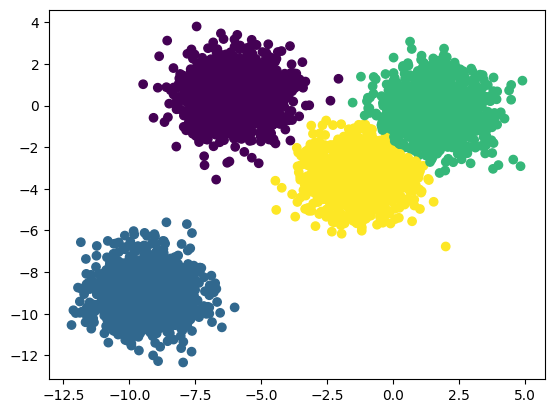

In [12]:
plt.scatter(x[:,0], x[:,1],c=predict)

The same plot again, with the important things marked:

- **red X** — the 4 centroids, the 8 numbers that *are* the model
- **black star** — the new customer from the cell above


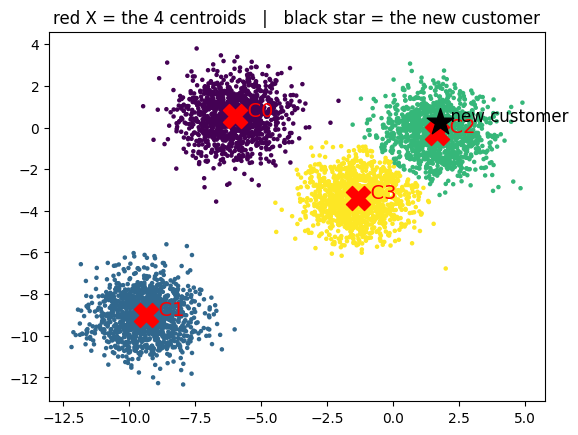

In [13]:
centers = kmeans.cluster_centers_

plt.scatter(x[:, 0], x[:, 1], c=predict, s=5)
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=300)

for i in range(4):
    plt.text(centers[i, 0], centers[i, 1], f"  C{i}", fontsize=14, color="red")

plt.scatter(new_customer[0][0], new_customer[0][1], c="black", marker="*", s=400)
plt.text(new_customer[0][0], new_customer[0][1], "  new customer", fontsize=12)

plt.title("red X = the 4 centroids   |   black star = the new customer")
plt.show()

Look at which coloured area the black star landed in. That colour is the number `predict`
returned. The model did not think about it any harder than that — nearest red X wins.

One more thing about the colours: the group numbers `0, 1, 2, 3` are **only ids**. Run the
notebook again and the same clump may come back as a different number. There is no correct
numbering, because nobody ever defined one.


## 6. Part two of the story — where K-Means gets it wrong

New data, new shape. `make_moons` builds two curved groups hooked into each other, like two
hands holding on.

Imagine two walking paths through a park that curve around each other. People on the same path
belong together, even though the path bends.

Note that `x, y` are reused here, so the customer data is gone from this point on.


In [14]:
x, y = make_moons(n_samples=1000, noise=0.06)

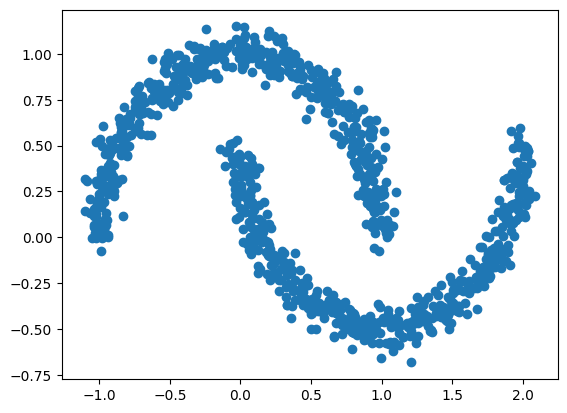

In [15]:
plt.scatter(x[:,0], x[:,1])

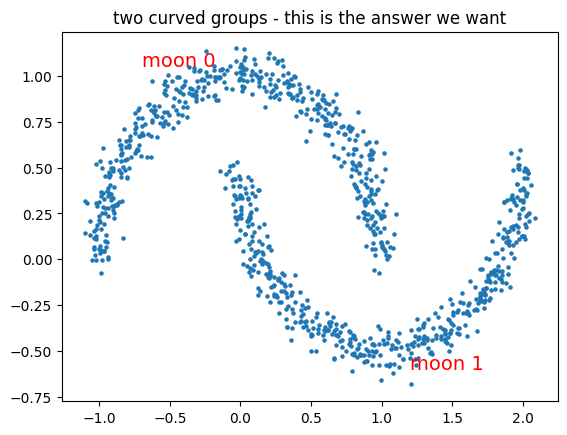

In [16]:
plt.scatter(x[:, 0], x[:, 1], s=5)

plt.text(-0.7, 1.05, "moon 0", fontsize=14, color="red")
plt.text(1.2, -0.6, "moon 1", fontsize=14, color="red")

plt.title("two curved groups - this is the answer we want")
plt.show()

Two clear curved groups. Your eye separates them instantly.

This is the answer we want. Now watch K-Means try.


We ask for 2 groups, because there are clearly 2 shapes.


In [17]:
kmeans = KMeans(n_clusters=2)

In [18]:
kmeans.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 2)",

In [19]:
predict = kmeans.predict(x)

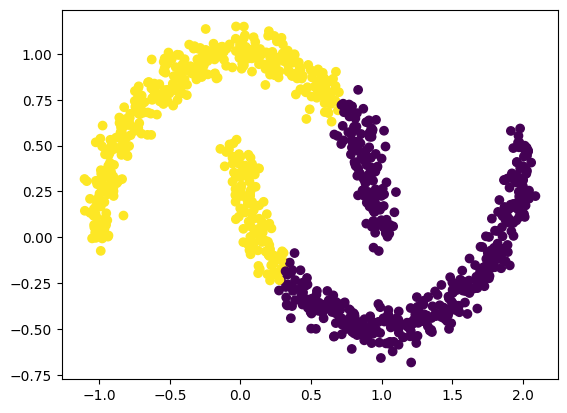

In [20]:
plt.scatter(x[:,0], x[:,1],c=predict)

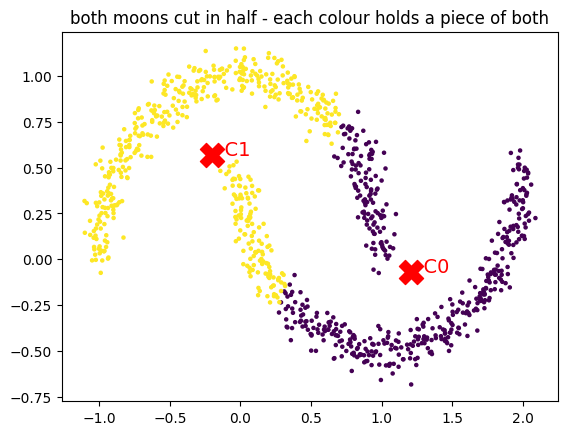

In [21]:
centers = kmeans.cluster_centers_

plt.scatter(x[:, 0], x[:, 1], c=predict, s=5)
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=300)

plt.text(centers[0, 0], centers[0, 1], "  C0", fontsize=14, color="red")
plt.text(centers[1, 0], centers[1, 1], "  C1", fontsize=14, color="red")

plt.title("both moons cut in half - each colour holds a piece of both")
plt.show()

This is wrong, and it is worth understanding *why* it is wrong.

K-Means asks only one question: **"which centre is nearer?"** Look at where the two red X marks
sit — in empty space, in the hollow of the curves.

The far end of one moon is physically closer to the *other* moon's centre than to its own. So it
gets the other colour. K-Means was not confused; it answered its own question perfectly. But
that question cannot describe a curve.

**The rule to remember:** K-Means works on round, separated, similar-sized groups. Long or
curved shapes need a different method.


## 7. Hierarchical clustering — a different way to group

Opposite idea. No K at the start, no centroids at all.

### The story

A party begins with everyone standing alone. Two friends spot each other and stand together. A
third person joins that pair. Elsewhere another small circle forms. Slowly the circles merge,
until the whole hall is one crowd.

Hierarchical clustering records that whole story of who joined whom, and lets you stop at any
point.

### The steps

1. every point starts as its own cluster — 1000 points means 1000 clusters
2. find the two **closest** clusters and merge them
3. repeat until only one cluster is left

The record of those merges is the **dendrogram** in your notes. Its height shows how far apart
two things were when they merged: merged low means very similar, merged high means very
different. To get 2 groups, you cut across the tallest vertical line.


In [22]:
from sklearn.cluster import AgglomerativeClustering

### `linkage` — the one setting that matters

A cluster is a group of points, not a single point. So "distance between two clusters" needs a
definition. That definition is `linkage`.

| linkage | it measures the distance between |
|---|---|
| `single` | the **closest** pair of points, one from each cluster |
| `complete` | the **farthest** pair of points |
| `average` | the average of all pairs |
| `ward` (default) | how much the spread grows after merging |

Your notes also list **centroid** linkage, which compares the two centre points. `scipy` has it;
`sklearn` offers `ward` in its place.

We use `single` here. It merges on the closest pair, which lets a cluster grow along a chain of
near neighbours — and a moon is exactly a chain of near neighbours.

`n_clusters` is not given, so it uses the default `2`.


In [23]:
ag1 = AgglomerativeClustering(linkage='single')

In [24]:
ag1.fit(x)

,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'single'
,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sam

### Back to your question — this model has **no** `predict()`

`AgglomerativeClustering` gives you `fit()` and then `labels_`, and that is all.

Why: K-Means stored 4 centroids, so a new customer could be measured against them.
Hierarchical clustering stores **no centres**. It only holds the merge history of the exact
points you gave it. A new point has no place in that history, so there is nothing to measure it
against.

So the honest version of the earlier answer:

- **K-Means** — groups your data *and* can place new rows into those groups.
- **Hierarchical** — groups your data only. New rows mean running it again.

`labels_` below is one number per customer, `0` or `1`, in the same order as `x`.


In [25]:
ag1.labels_

array([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,

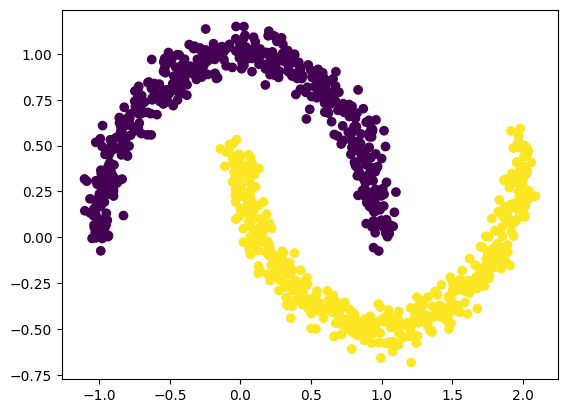

In [26]:
plt.scatter(x[:,0], x[:,1],c=ag1.labels_)

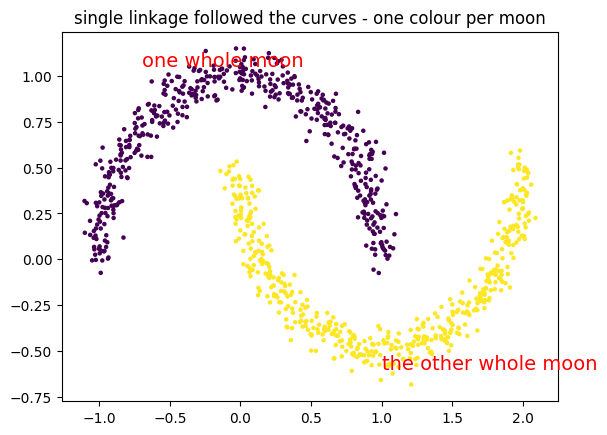

In [27]:
plt.scatter(x[:, 0], x[:, 1], c=ag1.labels_, s=5)

plt.text(-0.7, 1.05, "one whole moon", fontsize=14, color="red")
plt.text(1.0, -0.6, "the other whole moon", fontsize=14, color="red")

plt.title("single linkage followed the curves - one colour per moon")
plt.show()

Two clean moons, one colour each. The same data K-Means cut in half.

**Why it worked:** inside a moon the points sit in a chain, each one very close to its
neighbour. `single` linkage merges on the closest pair, so the merging walks along the curve
from one end to the other. The gap between the two moons is wider than any gap inside a moon, so
the two moons never join.

## 8. Which one to use

| | K-Means | Agglomerative (hierarchical) |
|---|---|---|
| tell it K first? | yes | no, you cut the tree afterwards |
| shapes it can find | round groups only | any shape, depends on linkage |
| what it stores | the centroids | nothing, only the merge history |
| new rows | `predict()` works | not possible, run it again |
| speed on big data | fast | slow, it compares every pair |
| how you choose the number of groups | elbow plot | dendrogram |

**If you remember only one thing:** clustering has no answer column, so it groups rows by
distance alone. K-Means measures distance to a **centre**, so it can only draw round groups, and
because it keeps those centres it can also place new rows. Hierarchical clustering measures
distance **between points**, so it can follow any shape, but it keeps nothing to reuse.
